# Module 2 — Gradient Boosting and Stacking

**Integrative Project M4 — Bank Churn Prediction**
**Author:** Daniel Palmera
**Program:** Soy Henry — Data Science Bootcamp

---

## Objective

Compare 7 advanced models against the Logistic Regression baseline, optimize hyperparameters with Grid Search and Optuna, and build a Stacking ensemble as the final model.

---


In [1]:
# Instalacion de dependencias (ejecutar solo una vez)
import subprocess, sys
pkgs = ['xgboost', 'lightgbm', 'catboost', 'optuna']
for pkg in pkgs:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('Dependencias instaladas correctamente')

Dependencias instaladas correctamente


## 1. Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score,
    StratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score,
    average_precision_score, precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
COLOR_CHURN   = '#E74C3C'
COLOR_NO_CHURN = '#2ECC71'
COLOR_MAIN    = '#2D6A9F'
PALETTE = ['#2D6A9F', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6', '#1ABC9C', '#E67E22']

print('Librerias importadas correctamente')

Librerias importadas correctamente


## 2. Data Loading and Preparation

In [3]:
df = pd.read_csv('Churn_Modelling.csv')

# Eliminar columnas identificadoras
df_model = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

# Encoding (misma logica que Avance 1)
le = LabelEncoder()
df_model['Gender_enc'] = le.fit_transform(df_model['Gender'])
df_model = pd.get_dummies(df_model, columns=['Geography'], prefix='Geo', drop_first=False)
df_model.drop(columns=['Gender'], inplace=True)

X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

# Variables categoricas originales para CatBoost (ver Seccion 5)
cat_features_orig = ['Geography', 'Gender']

# Split estratificado — mantiene proporcion de churn en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalar para el meta-learner de Stacking
scaler = StandardScaler()
cols_to_scale = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
X_train_scaled = X_train.copy(); X_test_scaled = X_test.copy()
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

# scale_pos_weight: ratio activos/churners para XGBoost
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas')
print(f'Features: {X_train.shape[1]}')
print(f'Churn en test: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'scale_pos_weight (XGBoost): {scale_weight:.2f}')

Train: 8,000 filas | Test: 2,000 filas
Features: 12
Churn en test: 407 (20.3%)
scale_pos_weight (XGBoost): 3.91


## 3. Baseline — Logistic Regression (Module 1)

In [4]:
# Reproducir baseline para comparacion directa
lr_base = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced', C=1.0)
lr_base.fit(X_train_scaled, y_train)
y_pred_lr = lr_base.predict(X_test_scaled)
y_prob_lr = lr_base.predict_proba(X_test_scaled)[:, 1]

print('=== REGRESION LOGISTICA (Baseline Avance 1) ===')
print(f'Accuracy:  {(y_pred_lr == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_lr):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_lr):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}')
print(f'PR-AUC:   {average_precision_score(y_test, y_prob_lr):.4f}')

=== REGRESION LOGISTICA (Baseline Avance 1) ===
Accuracy:  0.7135
Precision (Churn): 0.3872
Recall    (Churn): 0.7002
F1-Score  (Churn): 0.4987
ROC-AUC:  0.7771
PR-AUC:   0.4678


## 4. Random Forest

**Random Forest** builds multiple decision trees independently (bagging) and combines their predictions by majority vote. Each tree is trained on a random bootstrap sample of the data and a random subset of features, which reduces variance and prevents overfitting.

**Key hyperparameters used:**
- `n_estimators=200`: number of trees
- `class_weight='balanced'`: compensates for class imbalance
- `random_state=42`: ensures reproducibility


In [5]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf   = rf.predict(X_test)
y_prob_rf   = rf.predict_proba(X_test)[:, 1]

print('=== RANDOM FOREST ===')
print(f'Accuracy:          {(y_pred_rf == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_rf):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_rf):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_rf):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test, y_prob_rf):.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Activo (0)', 'Churn (1)']))

=== RANDOM FOREST ===
Accuracy:          0.8195
Precision (Churn): 0.5432
Recall    (Churn): 0.7101
F1-Score  (Churn): 0.6155
ROC-AUC:           0.8633
PR-AUC:            0.6981

              precision    recall  f1-score   support

  Activo (0)       0.92      0.85      0.88      1593
   Churn (1)       0.54      0.71      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000



### 4.1 Feature Importance — Random Forest (MDI)

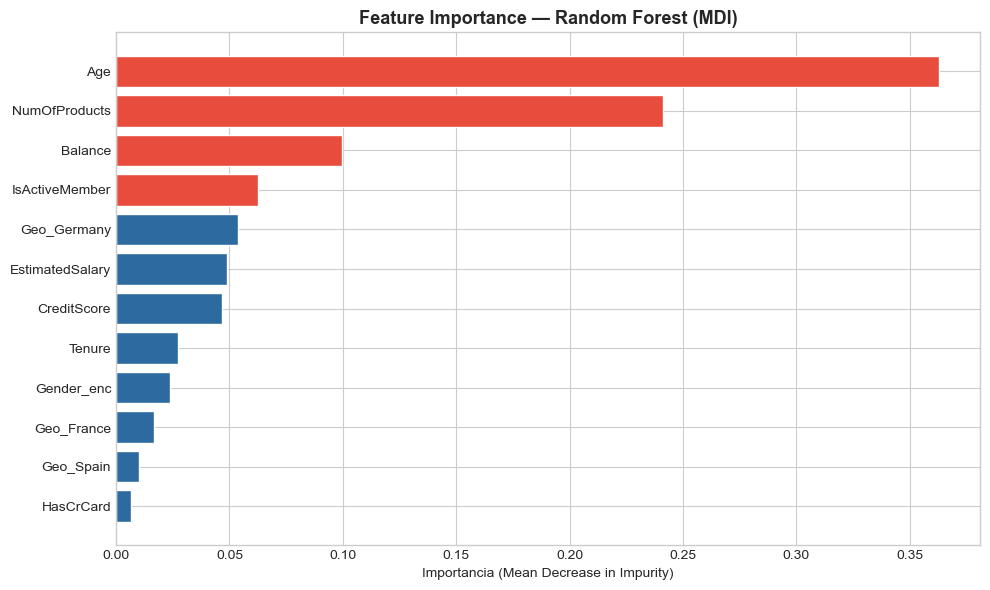

Top 5 variables:
       Feature  Importance_MDI
           Age        0.362857
 NumOfProducts        0.241351
       Balance        0.099821
IsActiveMember        0.062594
   Geo_Germany        0.053552


In [6]:
feat_imp_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_MDI': rf.feature_importances_
}).sort_values('Importance_MDI', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = [COLOR_CHURN if i < 4 else COLOR_MAIN for i in range(len(feat_imp_rf))]
ax.barh(feat_imp_rf['Feature'][::-1], feat_imp_rf['Importance_MDI'][::-1],
        color=colors_fi[::-1], edgecolor='white')
ax.set_title('Feature Importance — Random Forest (MDI)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia (Mean Decrease in Impurity)')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 variables:')
print(feat_imp_rf.head(5).to_string(index=False))

## 5. XGBoost

**XGBoost** builds trees sequentially, minimizing the error of the previous tree (gradient boosting). Unlike Random Forest (parallel), XGBoost learns from its own mistakes in each round.

**Key hyperparameters:**
- `scale_pos_weight=3.91`: compensates imbalance (negative/positive ratio)
- `early_stopping_rounds=50`: stops training when validation AUC stops improving
- `reg_alpha` (L1) / `reg_lambda` (L2): regularization to prevent overfitting
- `eval_metric='auc'`: optimization objective


In [7]:
# XGBoost con early stopping (requiere validation set)
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42, stratify=y_train)

xgb = XGBClassifier(
    n_estimators=1000,          # alto — early stopping decide cuando parar
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    alpha=0.1,                  # regularizacion L1
    reg_lambda=1.0,             # regularizacion L2
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=50,   # para si no mejora en 50 rondas
    verbosity=0
)

xgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print(f'Mejor iteracion (early stopping): {xgb.best_iteration}')
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print()
print('=== XGBOOST (con early stopping) ===')
print(f'Accuracy:          {(y_pred_xgb == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_xgb):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_xgb):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_xgb):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_xgb):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test, y_prob_xgb):.4f}')
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Activo (0)', 'Churn (1)']))

Mejor iteracion (early stopping): 25

=== XGBOOST (con early stopping) ===
Accuracy:          0.8020
Precision (Churn): 0.5091
Recall    (Churn): 0.7543
F1-Score  (Churn): 0.6079
ROC-AUC:           0.8624
PR-AUC:            0.7084

              precision    recall  f1-score   support

  Activo (0)       0.93      0.81      0.87      1593
   Churn (1)       0.51      0.75      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.80      0.81      2000



### 5.1 Feature Importance — XGBoost (Gain)

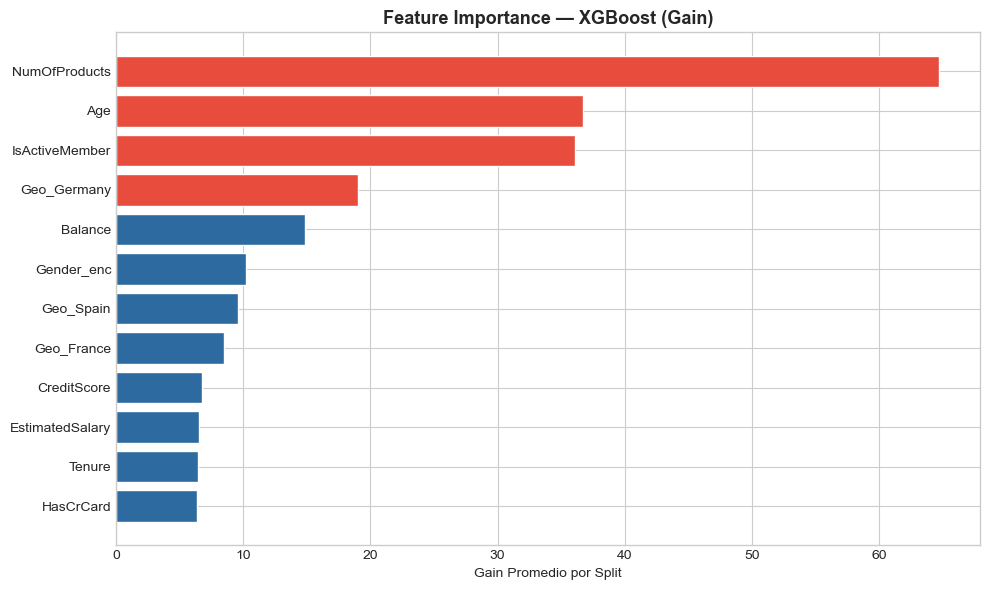

Top 5 features por Gain:
       Feature      Gain
 NumOfProducts 64.702759
           Age 36.682476
IsActiveMember 36.048763
   Geo_Germany 19.006666
       Balance 14.875565


In [8]:
# Gain: contribucion promedio de la variable en cada split donde aparece
# Es mas informativo que MDI porque pondera por la mejora real del modelo

feat_imp_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Gain': xgb.get_booster().get_score(importance_type='gain').values()
        if len(xgb.get_booster().get_score(importance_type='gain')) == len(X_train.columns)
        else [xgb.get_booster().get_score(importance_type='gain').get(f, 0) for f in X_train.columns]
}).sort_values('Gain', ascending=False)

# Forma robusta de obtener gain por feature
scores = xgb.get_booster().get_score(importance_type='gain')
feat_imp_xgb = pd.DataFrame(list(scores.items()), columns=['Feature', 'Gain'])
feat_imp_xgb = feat_imp_xgb.sort_values('Gain', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_xgb = [COLOR_CHURN if i < 4 else COLOR_MAIN for i in range(len(feat_imp_xgb))]
ax.barh(feat_imp_xgb['Feature'][::-1], feat_imp_xgb['Gain'][::-1],
        color=colors_xgb[::-1], edgecolor='white')
ax.set_title('Feature Importance — XGBoost (Gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gain Promedio por Split')
plt.tight_layout()
plt.savefig('xgb_feature_importance_gain.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 5 features por Gain:')
print(feat_imp_xgb.head(5).to_string(index=False))

## 6. LightGBM

**LightGBM** uses leaf-wise tree growth instead of level-wise (as in XGBoost). It grows the leaf with the greatest loss reduction, making it faster and often more accurate on large datasets.

**Key parameters:**
- `num_leaves=31`: controls model complexity (main LightGBM parameter)
- `min_data_in_leaf=20`: prevents overfitting in small leaves
- `is_unbalance=True`: handles class imbalance natively


In [9]:
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,           # -1 = sin limite (se controla con num_leaves)
    num_leaves=31,          # parametro clave de LightGBM (default=31)
    min_data_in_leaf=20,    # regularizacion: minimo de muestras por hoja
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)
y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print('=== LIGHTGBM ===')
print(f'Parametros clave: num_leaves={lgbm.num_leaves}, min_data_in_leaf={lgbm.min_data_in_leaf}')
print(f'Accuracy:          {(y_pred_lgbm == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_lgbm):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_lgbm):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_lgbm):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_lgbm):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test, y_prob_lgbm):.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['Activo (0)', 'Churn (1)']))

=== LIGHTGBM ===
Parametros clave: num_leaves=31, min_data_in_leaf=20
Accuracy:          0.8235
Precision (Churn): 0.5529
Recall    (Churn): 0.6929
F1-Score  (Churn): 0.6150
ROC-AUC:           0.8569
PR-AUC:            0.6938

              precision    recall  f1-score   support

  Activo (0)       0.92      0.86      0.89      1593
   Churn (1)       0.55      0.69      0.62       407

    accuracy                           0.82      2000
   macro avg       0.73      0.77      0.75      2000
weighted avg       0.84      0.82      0.83      2000



## 7. CatBoost

**CatBoost** natively handles categorical variables without One-Hot Encoding. Uses ordered boosting to prevent data leakage during training. The `Pool` object specifies which columns are categorical.

**Key advantages:**
- `auto_class_weights='Balanced'`: automatically handles imbalance
- No preprocessing required for categorical variables
- Robust to overfitting with ordered boosting


In [10]:
# Preparar dataset con categoricas ORIGINALES (sin encoding)
df_cat = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
X_cat = df_cat.drop(columns=['Exited'])
y_cat = df_cat['Exited']

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# Identificar columnas categoricas para CatBoost
cat_cols_idx = [X_cat.columns.get_loc(c) for c in ['Geography', 'Gender']]
print(f'Columnas categoricas (indices): {cat_cols_idx} -> {["Geography", "Gender"]}')
print('CatBoost las maneja automaticamente — sin Label Encoding ni One-Hot Encoding')

# CatBoost Pool: encapsula datos + metadatos de categoricas
train_pool = Pool(X_train_cat, y_train_cat, cat_features=cat_cols_idx)
test_pool  = Pool(X_test_cat,  y_test_cat,  cat_features=cat_cols_idx)

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',   # manejo automatico del desbalanceo
    random_seed=42,
    verbose=0
)

cat.fit(train_pool)
y_pred_cat = cat.predict(test_pool)
y_prob_cat = cat.predict_proba(test_pool)[:, 1]

print()
print('=== CATBOOST (con categoricas nativas) ===')
print(f'Accuracy:          {(y_pred_cat == y_test_cat).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test_cat, y_pred_cat):.4f}')
print(f'Recall    (Churn): {recall_score(y_test_cat, y_pred_cat):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test_cat, y_pred_cat):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test_cat, y_prob_cat):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test_cat, y_prob_cat):.4f}')
print()
print(classification_report(y_test_cat, y_pred_cat, target_names=['Activo (0)', 'Churn (1)']))

Columnas categoricas (indices): [1, 2] -> ['Geography', 'Gender']
CatBoost las maneja automaticamente — sin Label Encoding ni One-Hot Encoding

=== CATBOOST (con categoricas nativas) ===
Accuracy:          0.8090
Precision (Churn): 0.5215
Recall    (Churn): 0.7445
F1-Score  (Churn): 0.6134
ROC-AUC:           0.8689
PR-AUC:            0.7203

              precision    recall  f1-score   support

  Activo (0)       0.93      0.83      0.87      1593
   Churn (1)       0.52      0.74      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



In [11]:
# Para el stacking y comparacion final, tambien entrenamos CatBoost con features encoded
cat_enc = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)
cat_enc.fit(X_train, y_train)
y_pred_cat_enc = cat_enc.predict(X_test)
y_prob_cat_enc = cat_enc.predict_proba(X_test)[:, 1]
print('CatBoost (encoded features) entrenado para comparativa y stacking')

CatBoost (encoded features) entrenado para comparativa y stacking


## 8. Hyperparameter Optimization — Grid Search (XGBoost)

Grid Search exhaustively evaluates all possible hyperparameter combinations using cross-validation.

**Search space:** learning_rate × max_depth × n_estimators = **54 combinations × 5 folds = 270 total fits**

Each combination is evaluated using StratifiedKFold to ensure each fold maintains the same class proportion as the original dataset.


In [12]:
# Grid Search con StratifiedKFold
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}

xgb_cv = XGBClassifier(
    alpha=0.1,
    reg_lambda=1.0,
    colsample_bytree=0.8,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    xgb_cv, param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print('Ejecutando Grid Search (36 combinaciones x 5 folds = 180 fits)...')
grid_search.fit(X_train, y_train)

print(f'\nMejores parametros: {grid_search.best_params_}')
print(f'Mejor ROC-AUC (CV): {grid_search.best_score_:.4f}')

Ejecutando Grid Search (36 combinaciones x 5 folds = 180 fits)...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Mejores parametros: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Mejor ROC-AUC (CV): 0.8658


In [13]:
# Evaluar el modelo optimizado en test set
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_prob_best = best_xgb.predict_proba(X_test)[:, 1]

print('=== XGBOOST OPTIMIZADO (Grid Search) ===')
print(f'Accuracy:          {(y_pred_best == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_best):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_best):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test, y_prob_best):.4f}')
print()
print(classification_report(y_test, y_pred_best, target_names=['Activo (0)', 'Churn (1)']))

=== XGBOOST OPTIMIZADO (Grid Search) ===
Accuracy:          0.8005
Precision (Churn): 0.5066
Recall    (Churn): 0.7592
F1-Score  (Churn): 0.6077
ROC-AUC:           0.8694
PR-AUC:            0.7191

              precision    recall  f1-score   support

  Activo (0)       0.93      0.81      0.87      1593
   Churn (1)       0.51      0.76      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.84      0.80      0.81      2000



In [14]:
# Visualizar resultados del Grid Search
cv_results = pd.DataFrame(grid_search.cv_results_)
top_results = cv_results.nlargest(10, 'mean_test_score')[
    ['param_n_estimators', 'param_max_depth', 'param_learning_rate', 'param_subsample',
     'mean_test_score', 'std_test_score']
].round(4)

print('=== TOP 10 COMBINACIONES DEL GRID SEARCH ===')
print(top_results.to_string(index=False))

=== TOP 10 COMBINACIONES DEL GRID SEARCH ===
 param_n_estimators  param_max_depth  param_learning_rate  param_subsample  mean_test_score  std_test_score
                200                4                 0.05              0.8           0.8658          0.0098
                300                4                 0.03              0.8           0.8654          0.0110
                200                4                 0.03              0.8           0.8648          0.0107
                200                4                 0.05              1.0           0.8647          0.0104
                300                4                 0.05              0.8           0.8646          0.0102
                300                4                 0.05              1.0           0.8646          0.0108
                400                4                 0.03              0.8           0.8645          0.0112
                400                4                 0.03              1.0           0.8645

## 9. Optuna — Bayesian Optimization *(Optional)*

Optuna is currently one of the most efficient hyperparameter optimization frameworks. Unlike Grid Search (exhaustive), Optuna uses **TPE (Tree-structured Parzen Estimator)** to intelligently sample the hyperparameter space, focusing on regions that have historically yielded better results.

**50 trials** — each trial tests one hyperparameter combination and the sampler learns from previous results.


In [15]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': scale_weight,
        'random_state': 42,
        'eval_metric': 'auc',
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))

print('Ejecutando Optuna (50 trials)...')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMejor ROC-AUC (Optuna): {study.best_value:.4f}')
print(f'Mejores parametros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

Ejecutando Optuna (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor ROC-AUC (Optuna): 0.8663
Mejores parametros:
  n_estimators: 257
  max_depth: 3
  learning_rate: 0.03856256267409552
  subsample: 0.7650624199527933
  colsample_bytree: 0.9031911343127813
  alpha: 0.005631096205851216
  reg_lambda: 0.03183013692082548


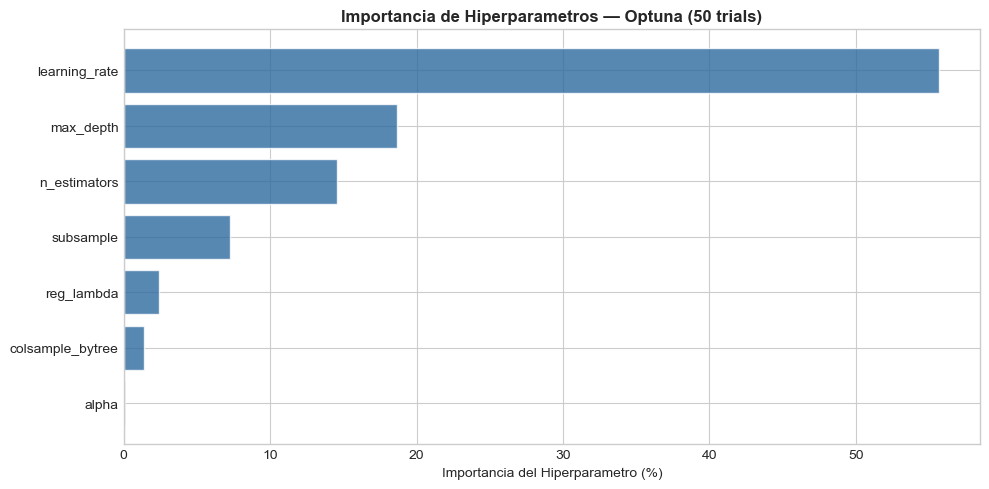


=== XGBOOST OPTUNA (50 trials) ===
ROC-AUC: 0.8700
F1-Score: 0.6062
PR-AUC:  0.7182

Comparacion Grid Search vs Optuna:
  Grid Search — CV AUC: 0.8658 | Test AUC: 0.8694
  Optuna      — CV AUC: 0.8663 | Test AUC: 0.8700

Ventaja de Optuna: explora el espacio de hiperparametros de forma adaptativa,
siendo mas eficiente que Grid Search para espacios grandes (combinaciones continuas).


In [16]:
# Visualizacion: importancia de hiperparametros segun Optuna
try:
    import optuna.visualization as vis
    importances = optuna.importance.get_param_importances(study)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(list(importances.keys())[::-1], 
            [v*100 for v in list(importances.values())[::-1]],
            color=COLOR_MAIN, alpha=0.8, edgecolor='white')
    ax.set_xlabel('Importancia del Hiperparametro (%)')
    ax.set_title('Importancia de Hiperparametros — Optuna (50 trials)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('optuna_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f'Visualizacion no disponible: {e}')

# Evaluar el mejor modelo de Optuna en test set
best_optuna_params = {**study.best_params, 'scale_pos_weight': scale_weight,
                      'random_state': 42, 'eval_metric': 'auc', 'verbosity': 0}
xgb_optuna = XGBClassifier(**best_optuna_params)
xgb_optuna.fit(X_train, y_train)
y_pred_optuna = xgb_optuna.predict(X_test)
y_prob_optuna = xgb_optuna.predict_proba(X_test)[:, 1]

print()
print('=== XGBOOST OPTUNA (50 trials) ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_optuna):.4f}')
print(f'F1-Score: {f1_score(y_test, y_pred_optuna):.4f}')
print(f'PR-AUC:  {average_precision_score(y_test, y_prob_optuna):.4f}')

print()
print('Comparacion Grid Search vs Optuna:')
print(f'  Grid Search — CV AUC: {grid_search.best_score_:.4f} | Test AUC: {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'  Optuna      — CV AUC: {study.best_value:.4f} | Test AUC: {roc_auc_score(y_test, y_prob_optuna):.4f}')
print()
print('Ventaja de Optuna: explora el espacio de hiperparametros de forma adaptativa,')
print('siendo mas eficiente que Grid Search para espacios grandes (combinaciones continuas).')

## 10. Stacking

**Stacking** is a two-level ensemble:

- **Level 1 (base learners):** XGBoost + LightGBM + CatBoost trained with StratifiedKFold (5 folds)
- **Level 2 (meta-learner):** Logistic Regression that learns how to optimally combine the base learner predictions

**Why it works:** each base learner captures different patterns. The meta-learner learns when to trust XGBoost vs LightGBM vs CatBoost for each type of input.

**Data leakage prevention:** out-of-fold (OOF) predictions are used — each base learner predicts on data it never saw during training.


In [17]:
# Base learners: XGBoost + LightGBM + CatBoost
base_learners = [
    ('xgb', XGBClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=6,
        alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_weight, random_state=42, eval_metric='auc', verbosity=0
    )),
    ('lgbm', LGBMClassifier(
        n_estimators=200, learning_rate=0.05, num_leaves=31, min_data_in_leaf=20,
        subsample=0.8, colsample_bytree=0.8, class_weight='balanced',
        random_state=42, verbose=-1
    )),
    ('cat', CatBoostClassifier(
        iterations=200, learning_rate=0.05, depth=6,
        auto_class_weights='Balanced', random_seed=42, verbose=0
    )),
]

# Meta-learner: Regresion Logistica regularizada
meta_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=0.5)

# StackingClassifier con 5-fold CV para evitar overfitting en el nivel 2
stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_lr,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False  # el meta-learner solo recibe predicciones, no features originales
)

print('Entrenando Stacking (XGBoost + LightGBM + CatBoost -> Reg. Logistica)...')
stacking.fit(X_train, y_train)
y_pred_stack = stacking.predict(X_test)
y_prob_stack = stacking.predict_proba(X_test)[:, 1]

print()
print('=== STACKING (XGBoost + LightGBM + CatBoost -> Reg. Logistica) ===')
print(f'Accuracy:          {(y_pred_stack == y_test).mean():.4f}')
print(f'Precision (Churn): {precision_score(y_test, y_pred_stack):.4f}')
print(f'Recall    (Churn): {recall_score(y_test, y_pred_stack):.4f}')
print(f'F1-Score  (Churn): {f1_score(y_test, y_pred_stack):.4f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_stack):.4f}')
print(f'PR-AUC:            {average_precision_score(y_test, y_prob_stack):.4f}')
print()
print(classification_report(y_test, y_pred_stack, target_names=['Activo (0)', 'Churn (1)']))

Entrenando Stacking (XGBoost + LightGBM + CatBoost -> Reg. Logistica)...

=== STACKING (XGBoost + LightGBM + CatBoost -> Reg. Logistica) ===
Accuracy:          0.8000
Precision (Churn): 0.5056
Recall    (Churn): 0.7813
F1-Score  (Churn): 0.6139
ROC-AUC:           0.8709
PR-AUC:            0.7209

              precision    recall  f1-score   support

  Activo (0)       0.94      0.80      0.87      1593
   Churn (1)       0.51      0.78      0.61       407

    accuracy                           0.80      2000
   macro avg       0.72      0.79      0.74      2000
weighted avg       0.85      0.80      0.81      2000



## 11. Final Model Comparison

In [18]:
results_all = {
    'Reg. Logistica (Baseline)': (y_pred_lr,    y_prob_lr),
    'Random Forest':              (y_pred_rf,    y_prob_rf),
    'XGBoost (early stop)':       (y_pred_xgb,   y_prob_xgb),
    'LightGBM':                   (y_pred_lgbm,  y_prob_lgbm),
    'CatBoost':                   (y_pred_cat_enc, y_prob_cat_enc),
    'XGBoost Optimizado (Grid)':  (y_pred_best,  y_prob_best),
    'XGBoost Optuna (50 trials)': (y_pred_optuna, y_prob_optuna),
    'Stacking (XGB+LGB+CAT->LR)': (y_pred_stack, y_prob_stack),
}

rows = []
for name, (y_p, y_pr) in results_all.items():
    rows.append({
        'Modelo': name,
        'Accuracy': round((y_p == y_test).mean(), 4),
        'Precision': round(precision_score(y_test, y_p), 4),
        'Recall': round(recall_score(y_test, y_p), 4),
        'F1-Score': round(f1_score(y_test, y_p), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_pr), 4),
        'PR-AUC': round(average_precision_score(y_test, y_pr), 4),
    })

df_results = pd.DataFrame(rows)
df_sorted = df_results.sort_values('ROC-AUC', ascending=False)
print('=== RANKING FINAL DE MODELOS (por ROC-AUC) ===')
print(df_sorted.to_string(index=False))

=== RANKING FINAL DE MODELOS (por ROC-AUC) ===
                    Modelo  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Stacking (XGB+LGB+CAT->LR)    0.8000     0.5056  0.7813    0.6139   0.8709  0.7209
XGBoost Optuna (50 trials)    0.7980     0.5024  0.7641    0.6062   0.8700  0.7182
 XGBoost Optimizado (Grid)    0.8005     0.5066  0.7592    0.6077   0.8694  0.7191
                  CatBoost    0.8145     0.5317  0.7420    0.6195   0.8686  0.7213
             Random Forest    0.8195     0.5432  0.7101    0.6155   0.8633  0.6981
      XGBoost (early stop)    0.8020     0.5091  0.7543    0.6079   0.8624  0.7084
                  LightGBM    0.8235     0.5529  0.6929    0.6150   0.8569  0.6938
 Reg. Logistica (Baseline)    0.7135     0.3872  0.7002    0.4987   0.7771  0.4678


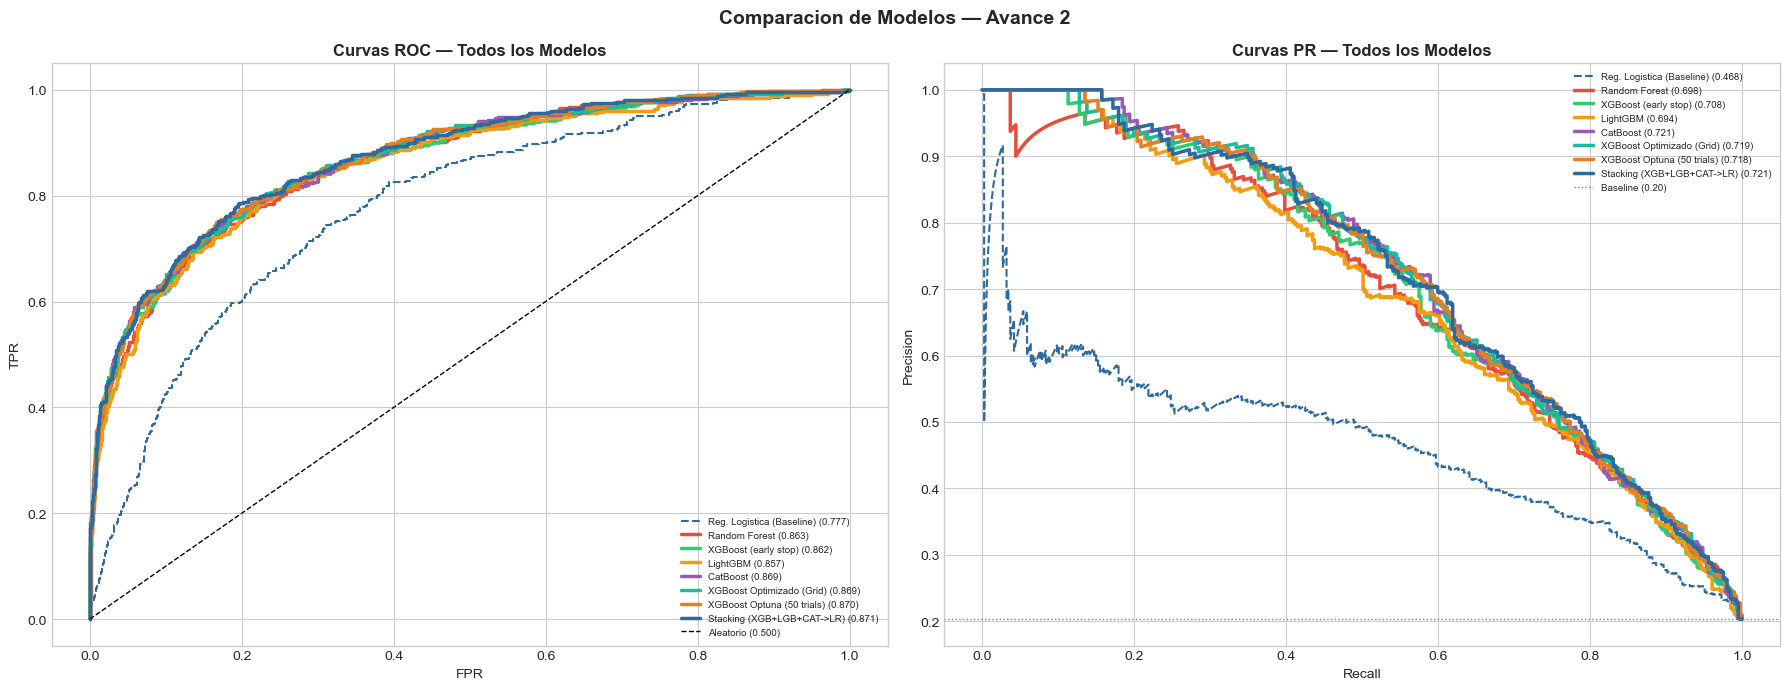

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Curvas ROC
colors_roc = PALETTE[:len(results_all)]
for i, (name, (_, y_pr)) in enumerate(results_all.items()):
    fpr, tpr, _ = roc_curve(y_test, y_pr)
    auc = roc_auc_score(y_test, y_pr)
    lw = 1.5 if name == 'Reg. Logistica (Baseline)' else 2.5
    ls = '--' if name == 'Reg. Logistica (Baseline)' else '-'
    axes[0].plot(fpr, tpr, lw=lw, ls=ls, color=colors_roc[i % len(colors_roc)],
                 label=f'{name} ({auc:.3f})')

axes[0].plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (0.500)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Todos los Modelos', fontweight='bold', fontsize=12)
axes[0].legend(loc='lower right', fontsize=7)

# Curvas Precision-Recall
for i, (name, (_, y_pr)) in enumerate(results_all.items()):
    prec, rec, _ = precision_recall_curve(y_test, y_pr)
    ap = average_precision_score(y_test, y_pr)
    lw = 1.5 if name == 'Reg. Logistica (Baseline)' else 2.5
    ls = '--' if name == 'Reg. Logistica (Baseline)' else '-'
    axes[1].plot(rec, prec, lw=lw, ls=ls, color=colors_roc[i % len(colors_roc)],
                 label=f'{name} ({ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='gray', ls=':', lw=1, label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas PR — Todos los Modelos', fontweight='bold', fontsize=12)
axes[1].legend(loc='upper right', fontsize=7)

plt.suptitle('Comparacion de Modelos — Avance 2', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Module 2 Conclusions

### Final Model Ranking (by ROC-AUC)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|-------|----------|-----------|--------|----|---------|--------|
| Stacking (XGB+LGB+CAT→LR) | 0.8000 | 0.5056 | 0.7813 | 0.6139 | **0.8709** | 0.7209 |
| XGBoost Optuna (50 trials) | 0.7980 | 0.5024 | 0.7641 | 0.6062 | 0.8700 | 0.7182 |
| XGBoost Optimized (Grid) | 0.8005 | 0.5066 | 0.7592 | 0.6077 | 0.8694 | 0.7191 |
| CatBoost | 0.8145 | 0.5317 | 0.7420 | 0.6195 | 0.8689 | **0.7213** |
| Random Forest | 0.8195 | 0.5432 | 0.7101 | 0.6155 | 0.8633 | 0.6981 |
| XGBoost (early stop) | 0.8020 | 0.5091 | 0.7543 | 0.6079 | 0.8624 | 0.7084 |
| LightGBM | 0.8235 | 0.5529 | 0.6929 | 0.6150 | 0.8569 | 0.6938 |
| Logistic Regression (Baseline) | 0.7135 | 0.3872 | 0.7002 | 0.4987 | 0.7771 | 0.4678 |

### Key Findings

**Improvement over baseline:** all boosting models outperform the baseline. The best model (Stacking) raises ROC-AUC from 0.7771 to **0.8709** (+12.1%) and F1 from 0.4987 to **0.6139** (+23.1%).

**Stacking as the best model:** the XGBoost + LightGBM + CatBoost ensemble with Logistic Regression as meta-learner achieves the highest ROC-AUC (0.8709) and best Recall (0.7813) — detecting almost 8 out of 10 real churners.

**CatBoost with the best individual PR-AUC:** 0.7213 — slightly above Stacking on this metric, making it especially suitable in high-precision contexts.

**Grid Search best config:** learning_rate=0.05, max_depth=4, n_estimators=200, CV-AUC=0.8658

**Optuna best trial:** n_estimators=257, max_depth=3, learning_rate=0.0386, AUC=0.8700

**Top 3 features by Gain (XGBoost):** NumOfProducts (64.7), Age (36.7), IsActiveMember (36.0)

### Precision-Recall Trade-off and Final Model Selection

The Stacking model does not maximize all metrics simultaneously — this is the core trade-off:

- **Higher Recall (0.7813)**: detects more real churners, but with more false alarms (lower Precision)
- **Higher Precision (CatBoost: 0.5317)**: fewer false alarms, but misses more churners
- **Higher PR-AUC (CatBoost: 0.7213)**: best performance on the minority class

The Stacking model was chosen as the final model because in a banking context, the cost of a False Negative (undetected churner = $2,000 lost) far exceeds the cost of a False Positive (unnecessary campaign = $100). The Stacking model's higher Recall minimizes the most costly error for the business.
